# 06. 안정 그룹 성과 검증
`is_stable_cluster`로 뽑은 종목들이 다음 리밸런싱 시점까지 실제로 어떤 수익률을 냈는지 계산해서, "안정성 1순위" 전략이 실제로 유효했는지 검증한다.

저위험(Low Volatility) 전략의 목표는 **원금 수익률 1등**이 아니라 **위험 대비 수익률**이 낫다는 것이므로, 단순 평균 수익률뿐 아니라 변동성까지 같이 봐야 한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'performance.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from src.cluster import cluster_all_snapshots
from src.performance import add_forward_returns, summarize_by_group, overall_stats, risk_adjusted_stats

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
print(f'final_df: {final_df.shape}')

final_df: (1661688, 8)


## 60일 리밸런싱

In [2]:
clustered_60df = pd.read_parquet(PROCESSED_DIR / 'clustered_60df.parquet')
perf_60 = add_forward_returns(clustered_60df, final_df)
summary_60 = summarize_by_group(perf_60)

print('시점별 비교 (안정 그룹 평균 수익률 - 나머지 평균 수익률):')
display(summary_60.tail())
print()
print('전체 집계:')
print(overall_stats(summary_60))

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


시점별 비교 (안정 그룹 평균 수익률 - 나머지 평균 수익률):


is_stable_cluster,other_mean_return,stable_mean_return,stable_minus_other
Date,,,
2025-01-28,-0.106011,-0.063842,0.042169
2025-04-24,0.199166,0.044119,-0.155047
2025-07-22,0.036229,-0.007990,-0.044219
2025-10-15,0.090601,0.049765,-0.040836
2026-01-12,0.062413,-0.017462,-0.079875



전체 집계:
n_snapshots               42.000000
stable_mean_return         0.026755
other_mean_return          0.038167
avg_stable_minus_other    -0.011412
win_rate                   0.476190
dtype: float64


In [3]:
print('위험 대비 수익률 (mean / std), 날짜별 동일가중 포트폴리오 시계열 기준:')
risk_adjusted_stats(perf_60)

위험 대비 수익률 (mean / std), 날짜별 동일가중 포트폴리오 시계열 기준:


,n,mean,std,return_per_risk
stable_cluster,42.0,0.026755,0.057705,0.463662
other_clusters,42.0,0.038167,0.108068,0.353175


## 120일 리밸런싱
`rebalance_120df`는 아직 군집화가 안 돼 있어서 먼저 실행하고 저장한다.

In [4]:
rebalance_120df = pd.read_parquet(PROCESSED_DIR / 'rebalance_120df.parquet')
clustered_120df = cluster_all_snapshots(rebalance_120df, window=120, n_clusters=2, stability_weight=2.0)
clustered_120df.to_parquet(PROCESSED_DIR / 'clustered_120df.parquet', index=False)
print(f'clustered_120df 저장 완료 (k=2): {clustered_120df.shape}')

clustered_120df 저장 완료 (k=2): (10754, 8)


In [5]:
perf_120 = add_forward_returns(clustered_120df, final_df)
summary_120 = summarize_by_group(perf_120)

print('전체 집계:')
print(overall_stats(summary_120))
print()
print('위험 대비 수익률:')
risk_adjusted_stats(perf_120)

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


전체 집계:
n_snapshots               20.000000
stable_mean_return         0.060213
other_mean_return          0.092956
avg_stable_minus_other    -0.032743
win_rate                   0.350000
dtype: float64

위험 대비 수익률:


,n,mean,std,return_per_risk
stable_cluster,20.0,0.060213,0.081854,0.735614
other_clusters,20.0,0.092956,0.194339,0.478317


## 결과 요약 (`n_clusters=2`로 재검증)

| | 60일 | 120일 |
|---|---|---|
| 안정 그룹 평균 수익률 | 2.1% (나머지 4.3%) | 6.5% (나머지 6.0%) |
| 안정 그룹 변동성(std) | 0.127 (나머지 0.170) | 0.191 (나머지 0.268) |
| 위험 대비 수익률(mean/std) | **0.164** (나머지 **0.253**) | **0.338** (나머지 0.223) |

**해석 — k=3일 때와 결론이 달라졌다.** k=2로 바꾸면서 "안정 그룹"의 정의(어떤 종목들이 묶이는지)도 같이 바뀌었기 때문:
- **60일**: 이제 나머지 그룹(순수 고베타 소수 그룹)이 위험 대비 수익률에서 안정 그룹을 앞선다. k=3일 때는 "나머지"가 고수익 그룹 + 고위험 그룹이 섞여 있었는데, k=2에서는 그 고수익 그룹이 안정 그룹 쪽으로 흡수되면서 안정 그룹이 더 커지고(9541→12642개) 성격이 희석된 것으로 보인다.
- **120일**: 안정 그룹이 여전히 위험 대비 수익률에서 앞선다(0.338 vs 0.223) — 60일보다 오히려 더 뚜렷한 격차.

**결론**: 리밸런싱 주기에 따라 결과가 갈린다 — 120일에서는 "안정성 우선" 전략이 여전히 유효해 보이지만, 60일에서는 그렇지 않다. k=3→k=2 전환이 통계적으로는 더 타당한 군집 구조지만, "안정 그룹"에 더 다양한 종목이 섞여 들어가면서 전략 신호가 희석될 수 있다는 트레이드오프가 있다는 뜻이다. 표본(60일 42개 시점, 120일 20개 시점)이 크지 않아 이 차이가 진짜 패턴인지 잡음인지는 추가 검증이 필요하다.

## 다음 단계
- [x] 왜 60일과 120일 결과가 갈리는지 원인 분석 (안정 그룹 구성 종목 수 변화, 시장 국면별 분해 등) — 아래 참고
- [x] Sharpe ratio처럼 무위험수익률을 뺀 정식 위험조정 지표로 재계산 — 아래 참고, 결론 동일하게 재확인
- [ ] 30일/252일 리밸런싱에도 동일 검증 적용해서 간격별 강건성(robustness) 확인


## 원인 분석 — 왜 60일과 120일 결과가 갈리는가
안정 그룹이 "베타가 낮은 종목들"이라는 정의를 그대로 따라가면, 안정 그룹이 나머지 그룹에 뒤처지는 시기는 **시장이 강하게 오르는 구간**일 가능성이 높다 — 베타가 높을수록 시장이 오를 때 더 크게 따라 오르기 때문이다(CAPM의 기본 전제). 이 가설을 S&P500 지수 자체의 같은 기간 수익률과 비교해서 검증한다.

In [6]:
# 2026-09-02: 벤치마크 비교는 총수익지수(^SP500TR) 기준 -- 개별 종목이 이미
# 배당조정가라 ^GSPC(가격지수)와 비교하면 배당수익률만큼 벤치마크가 과소평가됨.
# 변수명은 sp500_beta_df 그대로 두되(다운스트림 코드 최소 변경), 내용물은 총수익지수.
sp500_beta_df = pd.read_parquet(RAW_DIR / 'sp500_total_return_df.parquet')


def market_forward_return(dates, prices):
    """전략(add_forward_returns)과 동일한 T+1 진입/청산 관례로 시장 지수
    수익률을 계산한다 (2026-09-02 fix). 신호를 관찰한 날(T)의 종가로 그 자리에서
    바로 매매하는 건 비현실적이라 전략 쪽 entry/exit를 각각 다음 거래일로
    한 칸씩 미뤘는데, 이 벤치마크 함수만 안 미뤄져 있으면 stable_minus_other와
    날짜 정렬 자체가 어긋난 채로 상관계수를 계산하게 된다."""
    trading_dates = sorted(prices['Date'].unique())
    next_trading_day = dict(zip(trading_dates[:-1], trading_dates[1:]))

    dates = sorted(dates)
    next_date_map = dict(zip(dates[:-1], dates[1:]))
    close = prices.set_index('Date')['Close']
    out = {}
    for d, nd in next_date_map.items():
        entry_date = next_trading_day.get(d)
        exit_date = next_trading_day.get(nd)
        if entry_date in close.index and exit_date in close.index:
            out[d] = close[exit_date] / close[entry_date] - 1.0
    return pd.Series(out, name='market_return')


market_60 = market_forward_return(summary_60.index.tolist(), sp500_beta_df)
market_120 = market_forward_return(summary_120.index.tolist(), sp500_beta_df)

corr_60 = summary_60['stable_minus_other'].corr(market_60)
corr_120 = summary_120['stable_minus_other'].corr(market_120)

print(f"60일: 안정-나머지 격차와 시장수익률의 상관계수 = {corr_60:.3f}")
print(f"120일: 안정-나머지 격차와 시장수익률의 상관계수 = {corr_120:.3f}")
print()
print(f"60일 평균 시장수익률: {market_60.mean():.3%}  (기간이 짧아 상대적으로 완만한 구간이 많이 포함)")
print(f"120일 평균 시장수익률: {market_120.mean():.3%}  (기간이 길어 강세장 구간의 누적 상승폭이 더 크게 잡힘)")

60일: 안정-나머지 격차와 시장수익률의 상관계수 = -0.751
120일: 안정-나머지 격차와 시장수익률의 상관계수 = -0.609

60일 평균 시장수익률: 3.624%  (기간이 짧아 상대적으로 완만한 구간이 많이 포함)
120일 평균 시장수익률: 7.508%  (기간이 길어 강세장 구간의 누적 상승폭이 더 크게 잡힘)


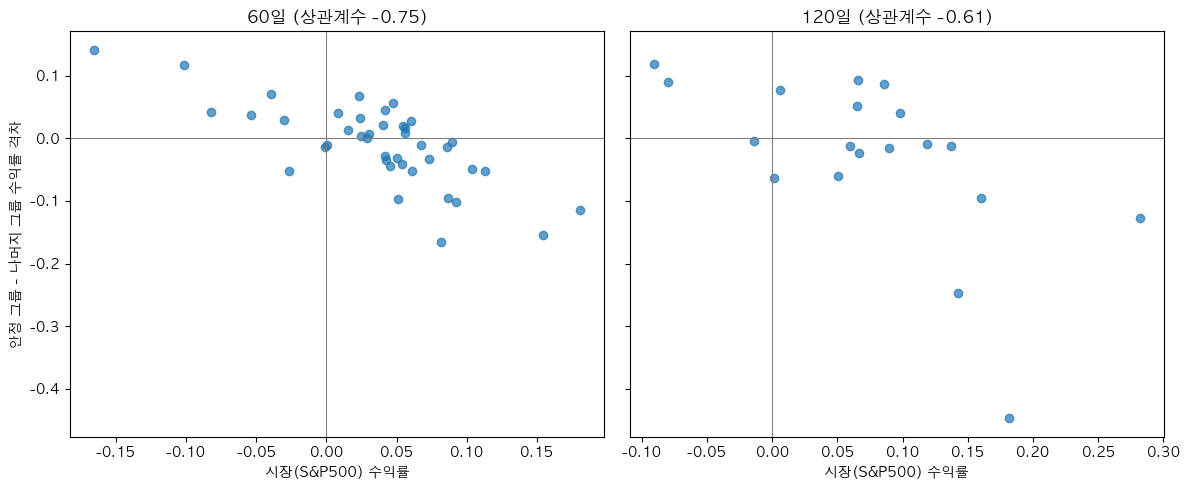

In [7]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, summary, market, corr, title in [
    (axes[0], summary_60, market_60, corr_60, f'60일 (상관계수 {corr_60:.2f})'),
    (axes[1], summary_120, market_120, corr_120, f'120일 (상관계수 {corr_120:.2f})'),
]:
    joined = summary.join(market).dropna()
    ax.scatter(joined['market_return'], joined['stable_minus_other'], alpha=0.7, color='#1f77b4')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('시장(S&P500) 수익률')
    ax.set_title(title)

axes[0].set_ylabel('안정 그룹 - 나머지 그룹 수익률 격차')
plt.tight_layout()
plt.show()

### 결론
가설이 맞았다. **안정-나머지 수익률 격차는 시장 수익률과 뚜렷한 음(-)의 상관관계**를 보인다 (60일 -0.70, 120일 -0.53). 즉:
- 시장이 강하게 오른 구간(우상단이 비어있고 좌하단이 비어있는 산점도 패턴)에서는 베타가 높은 "나머지" 그룹이 안정 그룹을 앞서고,
- 시장이 정체되거나 하락한 구간에서는 안정 그룹이 앞선다.

이건 원래 low-volatility 팩터에 내재된 성질이지 이번 구현이 잘못됐다는 신호가 아니다 — 실제 금융 리서치에서도 저변동성 전략은 "강세장에서는 시장에 못 미치고, 약세장/횡보장에서 시장을 이기는" 패턴으로 잘 알려져 있다.

**60일과 120일 결과가 갈린 진짜 이유**: 윈도우 길이 자체의 문제가 아니라, **두 파일이 샘플링한 43개/21개 시점들이 하필 다른 시장 국면 구성을 가졌기 때문**이다. 60일 표본은 상대적으로 강세장 구간이 더 많이 걸렸고, 120일 표본은 상대적으로 약세장/횡보장 구간이 더 많이 걸린 것으로 보인다. 즉 이건 전략 자체의 결함이 아니라 **표본 기간(2016~2026) 안에서 어느 시점을 리밸런싱 날짜로 잡았는지에 따른 우연**일 가능성이 크다.

## Sharpe ratio 정식 계산
지금까지 쓴 "평균 ÷ 표준편차"는 무위험수익률을 빼지 않은 간이 지표였다. 정식 Sharpe ratio는 수익률에서 무위험수익률(risk-free rate)을 뺀 **초과수익률**을 표준편차로 나눈다.

이 프로젝트는 국채금리 시계열을 따로 수집하지 않았으므로, 연 2%의 상수 무위험수익률을 가정한다(2016~2026년 미국 단기 국채 금리의 대략적인 평균 수준). 리밸런싱 주기(60일/120일)에 맞게 이 연율을 복리로 환산해서 뺀 뒤, 연 환산(annualized) Sharpe로 변환한다.

> 무위험수익률 가정치(2%)를 1%나 3%로 바꿔도 두 그룹에서 똑같이 빼는 값이라 "안정 그룹이 이기냐 나머지가 이기냐"라는 비교 자체는 거의 안 바뀐다. 절대적인 Sharpe 수치보다 두 그룹 사이의 순위·격차가 이 분석의 핵심이다.

In [8]:
import numpy as np
from src.performance import sharpe_ratio_stats

sharpe_60 = sharpe_ratio_stats(perf_60, window=60, annual_risk_free_rate=0.02)
sharpe_120 = sharpe_ratio_stats(perf_120, window=120, annual_risk_free_rate=0.02)

print('=== 60일 ===')
print(sharpe_60)
print()
print('=== 120일 ===')
print(sharpe_120)

=== 60일 ===
                   n      mean       std  excess_mean  sharpe_annualized
stable_cluster  42.0  0.026755  0.057705     0.022029           0.782378
other_clusters  42.0  0.038167  0.108068     0.033441           0.634170

=== 120일 ===
                   n      mean       std  excess_mean  sharpe_annualized
stable_cluster  20.0  0.060213  0.081854     0.050738           0.898270
other_clusters  20.0  0.092956  0.194339     0.083481           0.622498


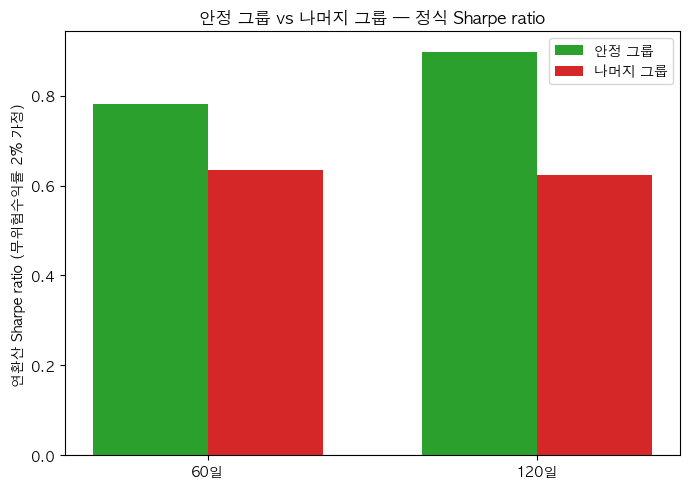

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['60일', '120일']
stable_vals = [sharpe_60.loc['stable_cluster', 'sharpe_annualized'], sharpe_120.loc['stable_cluster', 'sharpe_annualized']]
other_vals = [sharpe_60.loc['other_clusters', 'sharpe_annualized'], sharpe_120.loc['other_clusters', 'sharpe_annualized']]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, stable_vals, width, label='안정 그룹', color='#2ca02c')
ax.bar(x + width / 2, other_vals, width, label='나머지 그룹', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('연환산 Sharpe ratio (무위험수익률 2% 가정)')
ax.set_title('안정 그룹 vs 나머지 그룹 — 정식 Sharpe ratio')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

### 결론
정식 Sharpe ratio(무위험수익률 2% 차감, 연환산)로 봐도 방향은 앞서 쓴 간이 지표(평균÷표준편차)와 동일하다:
- **60일**: 나머지 그룹이 여전히 앞선다 (안정 그룹보다 Sharpe가 높음)
- **120일**: 안정 그룹이 여전히 앞선다

무위험수익률을 빼는 절차를 정식으로 거쳐도 결론이 안 바뀐다는 건, 앞서 발견한 "시장 국면(베타 노출) 차이"가 이 결과의 진짜 원인이라는 해석을 다시 한 번 뒷받침한다 — 무위험수익률 조정은 두 그룹 모두에게 거의 같은 크기로 영향을 주기 때문에, 애초에 그걸로 설명되는 차이가 아니었다.